# ARC-AGI-2 · Golden Fusion v3 — NVARC TTT+DFS (perfpatched) + TRM union
**Competition:** arc-prize-2026-arc-agi-2 · **Machine:** L4×4 (96 GB) · **Internet:** OFF · **Budget:** 12 h − 10 min

## Honest expectations
The best *public* notebook scores **LB 33.89** with exactly this NVARC recipe. This notebook is that
recipe + the LB33.89 performance patch (GPU-side DFS scoring → more puzzles finish in budget) + a
TRM (Tiny Recursive Model) union lane that can only **add** coverage, never displace a 4B answer.
Realistic LB range: **~33–36**. Anything promising 50+ from public components is not honest — the
two teams above ~40 use private methods.

## Required attachments (already wired in metadata)
| Kind | Source | Purpose |
|---|---|---|
| Model | `sorokin/qwen3_4b_grids15_sft139` (Transformers/bfloat16/1) | NVARC 2025 winner's Qwen3-4B grid-vocab SFT checkpoint |
| Utility kernel | `sorokin/pip-install-unsloth-flash-patch` | offline unsloth/flash-attn (FAST mode) |
| Dataset | `koushikrudra/trm-bundle` | TRM code + vendored deps (offline) |
| Dataset | `cpmpml/arc-prize-trm-031` | TRM `step_*` checkpoints (Phase B aborts without it) |
| Competition | `arc-prize-2026-arc-agi-2` | data + rerun input |

*Not attached:* `sorokin/nvarc-artifacts-puzzles` / `nvarc-synthetic-puzzles` — synthetic puzzles keyed
to the 120 **public eval** task ids. The hidden rerun uses **240 unseen tasks**, so they cannot help at
inference; their value is already distilled into the SFT checkpoint above (NVARC used them in training).

## Pipeline
`Phase A` 4 workers × 1 L4 each → per-puzzle LoRA TTT (r=256 incl. embed/lm_head, 128 augmented views,
1 epoch, lr 5e-5) → probability-floor DFS decode (p ≥ 0.2, 16 augmented views) → 8-view NLL re-scoring →
`score_kgmon` selection.  `Phase B` TRM test-time training from checkpoint (budget-capped) → union merge
(gap-fill only).  Deadline-safe: SJF task order, adaptive per-task caps, crash-safe submission guards.

## All settings (env knobs)
| Env | Default | Meaning |
|---|---|---|
| `ARC_SEED` | `0` | global seed offset (42+seed) |
| `ARC_DFS_MIN_P` | `0.17` | DFS cumulative-probability floor (v6: widened from 0.2) |
| `ARC_DEV_KEYS` | 8 dev ids | dev-mode puzzle filter; `*` = full eval set |
| `ARC_STALL_S` | `2400` | Phase A watchdog: stall window before killing wedged workers |
| `ARC_FORCE_COMPAT` | `0` | force pure transformers/peft path |
| `TRM_BUDGET_S` | `7200` | Phase B budget (dev-capped to 900) |
| `TRM_NAUG` | `128` | TRM augmentations (dev: 32) |
| `VIZ_N` | `6` | dev visualization: tasks rendered |

Dev commits run 4 puzzles + a short TRM pass (~30–60 min). The competition rerun
(`KAGGLE_IS_COMPETITION_RERUN`) runs the full hidden set for ~11.8 h.


In [1]:
import sys, os, time

global_end_time = time.time() + 12 * 3600 - 600

# ================== DUAL-MODE ENVIRONMENT SELECTOR ==================
# FAST   : Python 3.11 image (docker 31090)  -> sorokin utility (unsloth), original fast path
# COMPAT : Python 3.12+ image (current)      -> pure transformers/peft path, utility bypassed
# Override with ARC_FORCE_COMPAT=1 to force COMPAT even on 3.11.
_BAD = "pip_install_unsloth_flash_patch"

def _find_util():
    import glob as _g
    cands = (_g.glob("/kaggle/usr/lib/*/pip_install_unsloth_flash_patch")
             + _g.glob("/kaggle/usr/lib/pip_install_unsloth_flash_patch")
             + _g.glob("/kaggle/usr/lib/*/*/pip_install_unsloth_flash_patch"))
    return sorted(cands)[0] if cands else \
        "/kaggle/usr/lib/notebooks/sorokin/pip_install_unsloth_flash_patch"

UTIL = _find_util()

def _util_abi_ok():
    try:
        tag = f"cpython-{sys.version_info[0]}{sys.version_info[1]}"
        for sub in ("_core", "core"):  # numpy 2.x vs 1.x package layout
            core = os.path.join(UTIL, "numpy", sub)
            sos = [f for f in os.listdir(core) if f.endswith(".so")] if os.path.isdir(core) else []
            if sos:
                return any(tag in f for f in sos)
        return False
    except Exception:
        return False

force_compat = os.getenv("ARC_FORCE_COMPAT", "0") == "1"
use_fast = (not force_compat) and sys.version_info[:2] == (3, 11) and os.path.isdir(UTIL) and _util_abi_ok()

if use_fast:
    os.environ["ARC_COMPAT"] = "0"
    print(f"MODE=FAST   (Python {sys.version.split()[0]}, unsloth utility path)")
else:
    os.environ["ARC_COMPAT"] = "1"
    # scrub the ABI-incompatible utility packages from this kernel AND all child processes
    sys.path[:] = [p for p in sys.path if _BAD not in p]
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [p for p in os.environ.get("PYTHONPATH", "").split(os.pathsep) if p and _BAD not in p])
    import torch, transformers, peft, datasets  # fail fast if base image lacks the stack
    print(f"MODE=COMPAT (Python {sys.version.split()[0]}, torch {torch.__version__}, "
          f"transformers {transformers.__version__}, peft {peft.__version__})")
    if not torch.cuda.is_available():
        print("WARNING: CUDA not available in this session")


MODE=FAST   (Python 3.11.13, unsloth utility path)


In [2]:
!pip uninstall -y tensorflow

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0


In [3]:
%%writefile arc_loader.py
import json
import numpy as np
from transformers import AutoTokenizer


COMP_ROOTS = ("/kaggle/input/competitions/arc-prize-2026-arc-agi-2",
              "/kaggle/input/arc-prize-2026-arc-agi-2")

def comp_file(name):
    import os
    for root in COMP_ROOTS:
        p = os.path.join(root, name)
        if os.path.isfile(p):
            return p
    return os.path.join(COMP_ROOTS[0], name)


def convert_grid_to_string(grid) -> str:
    text = ""
    for row in grid:
        for cell in row:
            text += str(int(cell))
        text += "\n"
    return text.strip()

def is_valid_solution(guess):
    return isinstance(guess, np.ndarray) and guess.ndim == 2 and all(0 < x <= 30 for x in guess.shape)

def shuffled(data_list):
    return np.random.permutation(data_list).tolist()

def permute_mod(a, descriptor, invert=False):
    permutation = [int(i) for i in descriptor if str(i).isdigit()]
    assert sorted(permutation)==list(range(10))
    a = np.asarray(a)
    if a.ndim==3:
        if not invert: permutation = np.argsort(permutation)
        a = a[..., permutation]
    else:
        assert a.ndim==2
        if invert: permutation = np.argsort(permutation)
        a = np.asarray(permutation)[a]
    return a

def permute_rnd_all_(query):
    permutation = np.random.permutation(10).tolist()
    return 'permute' + ''.join(map(str, permutation))


class QwenFormatter:

    def __init__(self, tokenizer: AutoTokenizer):
        self.tokenizer = tokenizer

    def fmt_query(self, query) -> str:
        grid_input = convert_grid_to_string(query[0]["input"])
        return "<|im_start|>user\n" + grid_input + "<|im_end|><|im_start|>assistant\n"

    def fmt_reply(self, reply) -> str:
        return convert_grid_to_string(reply[0]) + "<|im_end|>"

    def fmt_train(self, train, last_is_challenge=False) -> str:
        if last_is_challenge:
            test = train[-1]
            train = train[:-1]
        else:
            test = None
        text = ""
        for x in train:
            grid_input = convert_grid_to_string(x["input"])
            grid_output = convert_grid_to_string(x["output"])
            text += f"<|im_start|>user\n{grid_input}<|im_end|><|im_start|>assistant\n{grid_output}<|im_end|>"
        if test is not None:
            text += self.fmt_query([test]) + self.fmt_reply([test["output"]])
        return text

    def max_new_tokens(self):
        max_sized_reply = np.zeros([30, 30], dtype=int)
        tokens = self.tokenizer.encode(self.fmt_reply([max_sized_reply]))
        return len(tokens) + 1

    def convert_tokens_to_array(self, tokens, limit_rows=30):
        if len(tokens) < 2:
            return None
        text = self.tokenizer.decode(tokens[:-1])
        try:
            lines = text.strip().split("\n")
            by_rows = [row for row in [[int(x) for x in line if x.isdigit()] for line in lines] if len(row)]
            if len(by_rows) > limit_rows:
                by_rows = by_rows[:limit_rows]
            array = np.array(by_rows, dtype=int)
            if is_valid_solution(array):
                return array
        except:
            pass
        return None


class ArcDataset:

    @staticmethod
    def forward_mod(a, key, use_perm=True):
        if a is None: return a
        for op in key.split('.')[1:]:
            if   op=='rot90':              a = np.rot90(a)
            elif op=='transpose':          a = np.swapaxes(a, 0, 1)
            elif op.startswith('permute'): a = permute_mod(a, op, invert=False) if use_perm else a
            elif op.startswith('copy'):    a = np.copy(a)
            elif op.startswith('out'):     a = a
            elif op.startswith('ex'):      a = a
            elif op.startswith('run'):     a = a
            else: raise NotImplementedError(f"Inversion of operation '{op}' unknown.")
        return a

    @staticmethod
    def invert_mod(a, key, inv_perm=True):
        if a is None: return a
        for op in key.split('.')[1:][::-1]:
            if   op=='rot90':              a = np.rot90(a, k=3)
            elif op=='transpose':          a = np.swapaxes(a, 0, 1)
            elif op.startswith('permute'): a = permute_mod(a, op, invert=True) if inv_perm else a
            elif op.startswith('copy'):    a = np.copy(a)
            elif op.startswith('out'):     a = a
            elif op.startswith('ex'):      a = a
            elif op.startswith('run'):     a = a
            else: raise NotImplementedError(f"Inversion of operation '{op}' unknown.")
        return a

    def __init__(self, queries, replies={}, keys=None, is_orig=False):
        if keys is not None: keys = [k for k in keys if k is not None]
        self.queries = queries if keys is None else {k: queries[k] for k in keys}
        self.replies = replies if keys is None else {k: replies[k] for k in keys if k in replies}
        self.is_orig = is_orig
        self.keys = sorted(queries.keys()) if keys is None else keys
        self.transposed_dataset = None

    def change_keys(self, keys, keep_flags=False):
        flags = dict(is_orig=self.is_orig) if keep_flags else {}
        return self.__class__(queries=self.queries, replies=self.replies, keys=keys, **flags)

    @classmethod
    def from_file(cls, queries_file, keys=None):
        with open(queries_file) as f:
            queries = f.read()
        return cls(
            queries=json.loads(queries),
            is_orig=True,
            keys=keys,
        )

    def load_replies(self, replies_file):
        print(f"*** Load solutions from '{replies_file}'...")
        with open(replies_file) as f: replies = f.read()
        replies_parsed = json.loads(replies)
        self.replies = {k: replies_parsed[k] for k in self.keys}
        return self

    def split_multi_replies(self):
        key_indices = [(k, i) for k in self.keys for i in range(len(self.queries[k]['test']))]
        return self.__class__(
            keys=[f'{k}_{i}' for k, i in key_indices],
            queries={f'{k}_{i}': {'train': self.queries[k]['train'], 'test': [self.queries[k]['test'][i]]} for k, i in key_indices},
            replies={f'{k}_{i}': [self.replies[k][i]] for k, i in key_indices if k in self.replies},
        )

    def shuffled(self):
        return self.__class__(queries=self.queries, replies=self.replies, keys=shuffled(self.keys))

    def append(*datasets):
        return datasets[0].__class__(
            queries={k: v for d in datasets for k, v in d.queries.items()},
            replies={k: v for d in datasets for k, v in d.replies.items()},
            keys   =[k    for d in datasets for k    in d.keys           ],
        )

    def mod_single(self, mod_func, descriptor, i, keep_key, inputs_only):
        queries = {}
        replies = {}
        keys    = []
        for k0 in self.keys:
            desc = (('copy{i}' if mod_func is np.copy else mod_func.__name__) if descriptor is None else descriptor if isinstance(descriptor, str) else descriptor(self.queries[k0])).format(i=i)
            func = lambda a, d: np.asarray(mod_func(a) if descriptor is None else mod_func(a, d)).tolist()
            k1 = k0 if keep_key else f"{k0}.{'I' if inputs_only else ''}{desc}"
            keys.append(k1)
            queries[k1] = {m: [{t: (func(a, desc) if t=='input' or not inputs_only else a) for t, a in x.items()} for x in e] for m, e in self.queries[k0].items()}
            if k0 in self.replies:
                replies[k1] = [func(a, desc) for a in self.replies[k0]]
        ret = self.__class__(queries=queries, replies=replies, keys=keys)
        return ret

    def mod(self, mod_func, descriptor=None, n=1, stack=None, keep=False, keep_key=False, shuffle=False, join=True, inputs_only=False):
        assert not (keep and keep_key)
        cur = self
        ret = [cur.shuffled() if shuffle else cur] if keep else []
        if stack is None: stack = mod_func.__name__.startswith('rot')
        for i in range(n):
            cur = (cur if stack else self).mod_single(mod_func, descriptor, i=i, keep_key=keep_key, inputs_only=inputs_only)
            ret.append(cur.shuffled() if shuffle else cur)
        return self.__class__.append(*ret) if join else ret

    def get(self, key, formatter: QwenFormatter):
        train = formatter.fmt_train(self.queries[key]['train'])
        query = formatter.fmt_query(self.queries[key]['test'])
        reply = formatter.fmt_reply(self.replies[key]) if key in self.replies else ''
        text = train+query+reply if reply else formatter.fmt_train(self.queries[key]['train'], last_is_challenge=True)
        return dict(key=key, train=train, query=query, reply=reply, input=train+query, text=text)

    def as_list(self, formatter: QwenFormatter):
        return [self.get(key, formatter) for key in self.keys]

    def get_length(self, key, formatter: QwenFormatter, name, max_of_transposed=False):
        if formatter is None:
            if   name=='input': return sum(np.prod(np.shape(v)) for v3 in self.queries[key].values() for v2 in v3 for v in v2.values())
            elif name=='reply': return sum(np.prod(np.shape(v)) for v in self.replies[key])
            else: assert False
        else:
            datasets = [self]
            if max_of_transposed:
                if self.transposed_dataset is None: self.transposed_dataset = self.mod(np.transpose, keep=False, keep_key=True)
                datasets.append(self.transposed_dataset)
            return max(len(formatter.tokenizer.encode(ds.get(key, formatter=formatter)[name])) for ds in datasets)

    def cut_to_len(self, formatter, name, max_len, from_end=False):
        temp_ds = self.change_keys(self.keys)
        new_keys = []
        new_queries = {}
        new_replies = {}
        for key in self.keys:
            reply = temp_ds.replies.get(key)
            while max_len<temp_ds.get_length(key, formatter=formatter, name=name):
                query = temp_ds.queries[key]
                if not key.split('.')[-1].startswith('ex'):
                    key = f"{key}.ex{''.join(map(str, range(len(query['train']))))}"
                key_split = key.split('.')
                assert key_split[-1].startswith('ex')
                key = '.'.join(key_split[:-1] + [f'ex{key_split[-1][2:-1] if from_end else key_split[-1][3:]}'])
                temp_ds.queries[key] = {k: ((v[:-1] if from_end else v[1:]) if k=='train' else v) for k, v in query.items()}
                if reply is not None:
                    temp_ds.replies[key] = reply
            new_keys.append(key)
            new_queries[key] = temp_ds.queries[key]
            if reply is not None: new_replies[key] = reply
        return self.__class__(keys=new_keys, queries=new_queries, replies=new_replies)
    
    def shuffle_ex(self, perm=None, keep_max=None):
        new_keys = []
        new_queries = {}
        new_replies = {}
        for key in self.keys:
            n = len(self.queries[key]['train'])
            p = np.random.permutation(n) if perm is None else perm
            if keep_max is not None: p = p[:keep_max]
            new_key = f'{key}.ex' + ('-' if (p.max()>9) else '').join(map(str, p.tolist()))
            new_keys.append(new_key)
            new_queries[new_key] = {k: (np.array(v, dtype=object)[p].tolist() if k=='train' else v) for k, v in self.queries[key].items()}
            if key in self.replies: new_replies[new_key] = self.replies[key]
        return self.__class__(queries=new_queries, replies=new_replies, keys=new_keys)

    def augment(self, n=1, shfl_keys=False, seed=42):
        np.random.seed(seed)
        d = self
        d = d.mod(np.transpose, keep=True)
        d = d.mod(np.rot90, n=3, keep=True)
        d = d.mod(permute_mod, permute_rnd_all_, n=n, shuffle=shfl_keys, keep=False)
        d = d.shuffle_ex()
        return d

    def get_submission(self, results=None):
        assert self.is_orig==True, 'Must be run on original dataset.'
        submission = {k: [{f'attempt_{i+1}': [[0]] for i in range(2)} for _ in range(len(self.queries[k]['test']))] for k in self.keys}
        if results is not None: self.fill_submission(results, submission)
        return submission

    @staticmethod
    def fill_submission(results, submission):
        print(f'*** Generating submission for {len(results)} outputs...')
        for k, v in results.items():
            base_id, base_nr = k.split('_')
            target_dict = submission[base_id][int(base_nr)]
            for i, g in enumerate(v[:len(target_dict)]):
                target_dict[f'attempt_{i+1}'] = g.tolist()

    def validate_submission(self, submission):
        assert self.is_orig==True, 'Must be run on original dataset.'
        score = 0
        for k, v in self.replies.items():
            for i, r in enumerate(v):
                for attempt in ['attempt_1', 'attempt_2']:
                    if np.array_equal(r, submission[k][i][attempt]):
                        score += 1 / len(v)
                        break
        return score

Writing arc_loader.py


In [4]:
%%writefile arc_decoder.py
import os
import bz2
import pickle
import numpy as np

def hashable(guess):
    return tuple(map(tuple, guess))

def score_sum(guesses, getter):
    guess_list = list(guesses.values())
    scores = {}
    for g in guess_list:
        h = hashable(g["solution"])
        x = scores[h] = scores.get(h, [[], g["solution"]])
        x[0].append(g)
    scores = [(getter(sc), o) for sc, o in scores.values()]
    scores = sorted(scores, key=(lambda x: x[0]), reverse=True)
    ordered_outputs = [x[-1] for x in scores]
    return ordered_outputs

def getter_full_probmul_3(guesses, baseline=3):
    inf_score = np.sum([baseline-g["beam_score"] for g in guesses])
    aug_score = np.mean([np.sum([baseline-s for s in g["score_aug"]]) for g in guesses])
    return inf_score + aug_score

def score_full_probmul_3(guesses):
    return score_sum(guesses, getter_full_probmul_3)

def getter_kgmon(guesses):
    inf_score = len(guesses)
    aug_score = np.mean([np.mean(g["score_aug"]) for g in guesses])
    return inf_score - aug_score

def score_kgmon(guesses):
    return score_sum(guesses, getter_kgmon)


def getter_hybrid_two(guesses):
    # benchmark-only candidate selector: occurrences - blended(aug NLL, best beam NLL)
    occ = len(guesses)
    aug = np.mean([np.mean(g["score_aug"]) for g in guesses])
    beam = np.min([g["beam_score"] for g in guesses])
    return occ - 0.7 * aug - 0.3 * beam

def score_hybrid_two(guesses):
    return score_sum(guesses, getter_hybrid_two)


selection_algorithms = [
    score_full_probmul_3,
    score_kgmon,
    score_hybrid_two,
]


class ArcDecoder:
    
    def __init__(self, dataset, n_guesses):
        self.dataset = dataset
        self.n_guesses = n_guesses
        self.decoded_results = {}

    def load_decoded_results(self, store, run_name=""):
        for key in os.listdir(store):
            try:
                with bz2.BZ2File(os.path.join(store, key)) as f:
                    outputs = pickle.load(f)
            except Exception as e:
                print(f"*** skipping corrupt result file {key}: {e!r}")
                continue
            base_key = key.split(".")[0]
            self.decoded_results[base_key] = self.decoded_results.get(base_key, {})
            for i, sample in enumerate(outputs):
                self.decoded_results[base_key][f"{key}{run_name}.out{i}"] = sample

    def run_selection_algo(self, selection_algorithm=score_kgmon):
        return {bk: selection_algorithm({k: g for k, g in v.items()}) for bk, v in self.decoded_results.items()}

    def benchmark_selection_algos(self):
        print("*** Benchmark selection algorithms...")

        labels = {}
        num_tasks_per_puzzle = {}
        num_solved_keys = 0
        num_total_keys = 0

        correct_beam_scores = []

        for basekey, basevalues in self.decoded_results.items():

            mult_key, mult_sub = basekey.split("_")
            num_tasks_per_puzzle[mult_key] = max(num_tasks_per_puzzle.get(mult_key, 0), int(mult_sub) + 1)

            labels[basekey] = correct_solution = self.dataset.replies[basekey][0]

            for subkey, sample in basevalues.items():

                solution = sample["solution"]
                beam_score = sample["beam_score"]
                aug_mean = np.mean(sample["score_aug"])

                if np.shape(correct_solution) != np.shape(solution):
                    corr_str = "bad_xy_size"
                elif np.array_equal(correct_solution, solution):
                    corr_str = "ALL_CORRECT"
                    num_solved_keys += 1
                    correct_beam_scores.append(beam_score)
                else:
                    corr_str = "bad_content"

                output_len = f"{solution.shape[0]}x{solution.shape[1]}"

                if corr_str == "ALL_CORRECT":
                    print(f"{corr_str}:{beam_score:8.5f} - {aug_mean:8.5f} {output_len:5s} [{subkey}]")
                num_total_keys += 1

        print(f" subkeys: {num_solved_keys}/{num_total_keys}")
        print(f" avg correct beam score: {np.mean(correct_beam_scores):8.5f}")
        print(f" max correct beam score: {np.max(correct_beam_scores):8.5f}")

        num_puzzles = len(num_tasks_per_puzzle)

        for selection_algorithm in selection_algorithms:
            name = selection_algorithm.__name__
            selected = self.run_selection_algo(selection_algorithm)
            correct_puzzles = {k for k, v in selected.items() if any(np.array_equal(guess, labels[k]) for guess in v[:self.n_guesses])}
            print(correct_puzzles)
            score = sum(1/num_tasks_per_puzzle[k.split("_")[0]] for k in correct_puzzles)
            print(f" acc: {score:5.1f}/{num_puzzles:3} ('{name}')")

Writing arc_decoder.py


In [5]:
%%writefile arc_solver.py
import os
import sys

COMPAT = os.getenv("ARC_COMPAT") == "1"
_BAD = "pip_install_unsloth_flash_patch"
if COMPAT:
    sys.path[:] = [p for p in sys.path if _BAD not in p]
    if "PYTHONPATH" in os.environ:
        os.environ["PYTHONPATH"] = os.pathsep.join(
            [p for p in os.environ["PYTHONPATH"].split(os.pathsep) if p and _BAD not in p])
else:
    from unsloth import FastLanguageModel, UnslothTrainingArguments, UnslothTrainer

from arc_loader import ArcDataset, QwenFormatter, comp_file

import gc
import os
import io
import time
import torch
import numpy as np
from tqdm import tqdm
from datasets import Dataset
from collections import defaultdict

from typing import Any, Union
from transformers import DataCollatorForLanguageModeling

import copy as _copy

if COMPAT:
    from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments
    from peft import LoraConfig, get_peft_model

import logging
from contextlib import redirect_stdout, redirect_stderr

from peft import get_peft_model_state_dict, set_peft_model_state_dict

import bz2
import zlib
import pickle

logging.disable(logging.WARNING)

ARC_VOCAB = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "Ċ": 10,
    "<|im_end|>": 15,
}

ARC_TOKENS = list(ARC_VOCAB.values())
USER_TOKEN_ID = 11
ASSISTANT_TOKEN_ID = 12
PAD_ID = 13
EOS_ID = 15


if COMPAT:
    _TrainerBase = Trainer
else:
    _TrainerBase = UnslothTrainer


class UnslothFixedTrainer(_TrainerBase):

    # Issue https://github.com/unslothai/unsloth/issues/2435

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """Fixed compute_loss that handles Unsloth's view tensor issue"""
        if self.label_smoother is not None and "labels" in inputs:
            labels = inputs.pop("labels")
        else:
            labels = None
        outputs = model(**inputs)
        if labels is not None:
            unwrapped_model = self.accelerator.unwrap_model(model)
            if hasattr(unwrapped_model, "_get_name") and "unsloth" in unwrapped_model._get_name().lower():
                loss = self.label_smoother(outputs, labels, shift_labels=True)
            else:
                loss = self.label_smoother(outputs, labels)
        else:
            loss = outputs["loss"] if isinstance(outputs, dict) else outputs[0]
        # 🔧 KEY FIX: Clone the loss tensor before in-place operations
        if hasattr(loss, "clone"):
            loss = loss.clone()  # Converts view tensor to independent tensor
        # Now safe for DDP gradient scaling
        if self.accelerator.num_processes > 1:
            loss = loss * self.accelerator.num_processes
        return (loss, outputs) if return_outputs else loss


class QwenDataCollatorForCompletionOnlyLM(DataCollatorForLanguageModeling):

    def torch_call(self, examples: list[Union[list[int], Any, dict[str, Any]]]) -> dict[str, Any]:
        batch = super().torch_call(examples)
        for i in range(len(examples)):
            labels = batch["input_ids"][i].clone()
            user_start_idx = np.where(labels == USER_TOKEN_ID)[0].tolist()
            assistant_start_idx = np.where(labels == ASSISTANT_TOKEN_ID)[0].tolist()
            start_idx = sorted(user_start_idx + assistant_start_idx)
            end_idx = np.where(labels == EOS_ID)[0]
            batch["labels"][i, :] = -100
            for j, (start, end) in enumerate(zip(start_idx, end_idx)):
                assert start < end
                if j % 2 == 1:
                    start += 2
                    end += 1
                    batch["labels"][i, start:end] = labels[start:end]
        return batch


_INPUT_ROOT = os.getenv("ARC_INPUT_ROOT", "/kaggle/input")


def resolve_model_path():
    """ARC_MODEL_PATH env -> sorokin default mount -> scan for a vocab_size==16
    grid model under /kaggle/input -> fail fast with an actionable listing."""
    import glob as _glob
    import json as _json
    cand = os.getenv("ARC_MODEL_PATH")
    if cand and os.path.isfile(os.path.join(cand, "config.json")):
        return cand
    default = os.path.join(_INPUT_ROOT, "qwen3_4b_grids15_sft139/transformers/bfloat16/1")
    if os.path.isfile(os.path.join(default, "config.json")):
        return default
    hits = []
    for cfg in _glob.glob(os.path.join(_INPUT_ROOT, "**", "config.json"), recursive=True):
        try:
            with open(cfg) as f:
                c = _json.load(f)
        except Exception:
            continue
        if c.get("vocab_size") == 16:
            hits.append(os.path.dirname(cfg))
    if hits:
        hits.sort(key=lambda p: ("bfloat16" not in p, "grids" not in p, len(p)))
        return hits[0]
    listing = "\n".join(sorted(_glob.glob(os.path.join(_INPUT_ROOT, "*")))) or "(empty)"
    raise RuntimeError(
        "ARC 4B model not found. Attach the Kaggle MODEL 'sorokin/qwen3_4b_grids15_sft139' "
        "(Add Input -> Models), or set ARC_MODEL_PATH to a model dir containing config.json.\n"
        f"Currently attached under {_INPUT_ROOT}:\n{listing}"
    )


def snapshot_cache(cache):
    """Branch-safe shallow snapshot of a HF cache.

    transformers v5 DynamicLayer.update() REBINDS layer.keys/.values via torch.cat,
    so copying the layers list + each layer object (tensors shared) fully isolates
    sibling DFS branches at zero memory cost. Legacy tuple caches are already
    functional and are returned as-is.
    """
    if cache is None or isinstance(cache, tuple):
        return cache
    try:
        return _snapshot_cache_fast(cache)
    except Exception:
        # exotic transformers builds may expose read-only cache attrs;
        # deepcopy is slow but branch-safe
        return _copy.deepcopy(cache)


def _snapshot_cache_fast(cache):
    new = _copy.copy(cache)
    for attr in ("key_cache", "value_cache"):
        if hasattr(cache, attr) and isinstance(getattr(cache, attr), list):
            setattr(new, attr, list(getattr(cache, attr)))
    layers = getattr(cache, "layers", None)
    if isinstance(layers, list):
        new_layers = []
        for layer in layers:
            nl = _copy.copy(layer)
            for lattr in ("keys", "values", "key_cache", "value_cache"):
                if isinstance(getattr(nl, lattr, None), list):
                    setattr(nl, lattr, list(getattr(nl, lattr)))
            new_layers.append(nl)
        new.layers = new_layers
    return new


def set_train_mode(model):
    if COMPAT:
        model.train()
        return model
    return FastLanguageModel.for_training(model)


def set_infer_mode(model):
    if COMPAT:
        try:
            model.gradient_checkpointing_disable()
        except Exception:
            pass
        model.eval()
        return model
    return FastLanguageModel.for_inference(model)


_ARC_TOKEN_ID_CACHE = {}


def _arc_token_ids(device):
    key = str(device)
    token_ids = _ARC_TOKEN_ID_CACHE.get(key)
    if token_ids is None:
        token_ids = torch.tensor(ARC_TOKENS, dtype=torch.long, device=device)
        _ARC_TOKEN_ID_CACHE[key] = token_ids
    return token_ids


def turbo_dfs(model, logits, max_new_tokens, max_score, scores, pos, cache, start_time, end_time) -> dict:

    n = logits.size(0)

    # LB33.89 perfpatch: algebraically identical to
    #   scores - logits.float().cpu().log_softmax(-1) restricted to ARC_TOKENS,
    # computed on GPU so only len(ARC_TOKENS) values per beam cross to CPU.
    logits_f = logits.float()
    token_ids = _arc_token_ids(logits.device)
    arc_logits = logits_f.index_select(-1, token_ids)
    nll = (
        torch.as_tensor(scores, dtype=torch.float32, device=logits.device).view(n, 1)
        + torch.logsumexp(logits_f, dim=-1, keepdim=True)
        - arc_logits
    ).cpu()

    suffixes = defaultdict(list)

    candidates = dict()

    for i in range(n):
        candidates[i] = []
        for token_idx, t in enumerate(ARC_TOKENS):
            score = nll[i, token_idx].item()
            if score < max_score:
                if t == EOS_ID:
                    suffixes[i].append((score, [t]))
                elif max_new_tokens > 1:
                    candidates[i].append((score, t))

    for i in range(n):
        candidates[i] = sorted(candidates[i], key=lambda x:x[0]) #[:5]
    
    while time.time() - start_time < 540 and time.time() < end_time:

        batch_tokens = []
        batch_scores = []
        num_alive_beams = 0

        for i in range(n):
            if len(candidates[i]) == 0:
                batch_tokens.append(PAD_ID)
                batch_scores.append(1000)
            else:
                score, t = candidates[i].pop(0)
                batch_tokens.append(t)
                batch_scores.append(score)
                num_alive_beams += 1

        if num_alive_beams == 0:
            break

        outputs = model(
            input_ids=torch.tensor(batch_tokens, device=model.device, dtype=torch.long).view(-1, 1),
            position_ids=torch.full((n, 1), pos, device=model.device),
            past_key_values=snapshot_cache(cache) if COMPAT else cache,
            return_dict=True,
            use_cache=True,
        )

        next_suffixes = turbo_dfs(
            model,
            logits=outputs.logits[:, -1],
            max_new_tokens=max_new_tokens-1,
            max_score=max_score,
            scores=batch_scores,
            pos=pos+1,
            cache=outputs.past_key_values,
            start_time=start_time,
            end_time=end_time,
        )

        for batch_id, beams in next_suffixes.items():
            for score, suffix_tokens in beams:
                suffix_tokens.insert(0, batch_tokens[batch_id])
                suffixes[batch_id].append((score, suffix_tokens))

    return suffixes


@torch.no_grad()
def inference_turbo_dfs(model, prefix_tokens, max_new_tokens, max_score, end_time):
    input_ids = torch.tensor(prefix_tokens, device=model.device, dtype=torch.long)
    outputs = model(input_ids=input_ids, return_dict=True, use_cache=True)
    suffixes = turbo_dfs(
        model,
        logits=outputs.logits[:, -1],
        max_new_tokens=max_new_tokens,
        max_score=max_score,
        scores=[0.0] * input_ids.size(0),
        pos=input_ids.size(1),
        cache=outputs.past_key_values,
        start_time=time.time(),
        end_time=end_time,
    )
    result = []
    for batch_id, beams in suffixes.items():
        sorted_beams = sorted(beams, key=lambda x:x[0])
        result.append((batch_id, sorted_beams))
    return result


@torch.no_grad()
def calc_scores(queries, answers, tokenizer, model):
    batch_query_tokens = []
    batch_answer_tokens = []
    batch_tokens = []
    batch_lengths = []
    for query, answer in zip(queries, answers):
        query_tokens = tokenizer.encode(query)
        answer_tokens = tokenizer.encode(answer)
        tokens = query_tokens + answer_tokens
        batch_query_tokens.append(query_tokens)
        batch_answer_tokens.append(answer_tokens)
        batch_tokens.append(tokens)
        batch_lengths.append(len(tokens))
    max_len = max(batch_lengths)
    padded_tokens = []
    for tokens in batch_tokens:
        padded = tokens + [PAD_ID] * (max_len - len(tokens))
        padded_tokens.append(padded)
    input_ids = torch.tensor(padded_tokens, device=model.device, dtype=torch.long)

    # LB33.89 perfpatch: keep logits on GPU and gather only target-token scores.
    # KV cache is not consumed by teacher-forced scoring; disabling it removes
    # redundant writes.
    outputs = model(input_ids=input_ids, return_dict=True, use_cache=False)
    batch_logits = outputs.logits.float()
    batch_log_norm = torch.logsumexp(batch_logits, dim=-1)
    result = []
    for row_id, (query_tokens, answer_tokens) in enumerate(zip(batch_query_tokens, batch_answer_tokens)):
        query_length = len(query_tokens)
        answer_length = len(answer_tokens)
        positions = torch.arange(
            query_length - 1,
            query_length - 1 + answer_length,
            device=model.device,
        )
        target_tokens = torch.tensor(answer_tokens, device=model.device, dtype=torch.long)
        answer_log_probs = (
            batch_logits[row_id, positions, target_tokens]
            - batch_log_norm[row_id, positions]
        )
        result.append(-answer_log_probs.sum().item())
    return result


def worker(rank, queue, end_time):

    rerun_mode = os.getenv("KAGGLE_IS_COMPETITION_RERUN")

    arc_seed = int(os.getenv("ARC_SEED", "0"))
    # deterministic LoRA/adapter init and any pre-augment RNG use (unsloth path had
    # random_state=42; peft LoraConfig has no such param, so seed globally here)
    torch.manual_seed(42 + arc_seed)
    np.random.seed(42 + arc_seed)

    peft_params = dict(
        r=256,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj", "embed_tokens", "lm_head"],
        lora_alpha=32,
        lora_dropout=0.0,
        bias="none",
        use_gradient_checkpointing=False,
        random_state=42,
        use_rslora=True,
        loftq_config=None,
    )

    train_args = dict(
        per_device_eval_batch_size=1,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=1,
        num_train_epochs=1,
        warmup_steps=0,
        warmup_ratio=0.1,
        max_grad_norm=1.0,
        learning_rate=5e-5,
        optim="adamw_torch",
        weight_decay=0.0,
        lr_scheduler_type="cosine",
        seed=42 + int(os.getenv("ARC_SEED", "0")),
        report_to="none",
        save_strategy="no",
        eval_strategy="no",
        logging_strategy="no",
        fp16=False,
        bf16=True,
        # Disable FSDP (use standard DDP)
        fsdp="",
        ddp_find_unused_parameters=False,
        dataloader_num_workers=0,
        gradient_checkpointing=False,
    )

    max_seq_length = 8192

    model_path = resolve_model_path()

    if COMPAT:
        tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token = tokenizer.convert_ids_to_tokens(PAD_ID)
        try:
            model = AutoModelForCausalLM.from_pretrained(
                model_path, dtype=torch.bfloat16,
                attn_implementation="sdpa", local_files_only=True)
        except TypeError:  # older transformers uses torch_dtype
            model = AutoModelForCausalLM.from_pretrained(
                model_path, torch_dtype=torch.bfloat16,
                attn_implementation="sdpa", local_files_only=True)
        if next(model.parameters()).dtype != torch.bfloat16:
            model = model.to(torch.bfloat16)
        if torch.cuda.is_available():
            model = model.cuda()
        model.config.use_cache = True
        lora_config = LoraConfig(
            r=peft_params["r"],
            target_modules=peft_params["target_modules"],
            lora_alpha=peft_params["lora_alpha"],
            lora_dropout=peft_params["lora_dropout"],
            bias=peft_params["bias"],
            use_rslora=peft_params["use_rslora"],
            task_type="CAUSAL_LM",
        )
        model = get_peft_model(model, lora_config)
        try:
            model.enable_input_require_grads()
        except Exception:
            pass
    else:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_path,
            full_finetuning=False,
            load_in_4bit=False,
            local_files_only=True,
            use_gradient_checkpointing=False,
            max_seq_length=max_seq_length,
        )
        model = FastLanguageModel.get_peft_model(model, **peft_params)

    for name, param in model.named_parameters():
        if param.dtype == torch.float32:
            param.data = param.data.to(torch.bfloat16)

    default_weights = get_peft_model_state_dict(model, adapter_name="default")
    default_weights = {k: v.clone().detach() for k, v in default_weights.items()}

    collator = QwenDataCollatorForCompletionOnlyLM(
        tokenizer=tokenizer,
        mlm=False,
    )

    formatter = QwenFormatter(tokenizer=tokenizer)

    max_new_tokens = formatter.max_new_tokens()

    max_score = -np.log(float(os.getenv("ARC_DFS_MIN_P", "0.2")))

    if rerun_mode:
        test_path = comp_file("arc-agi_test_challenges.json")
    else:
        test_path = comp_file("arc-agi_evaluation_challenges.json")

    arc_test_set = ArcDataset.from_file(test_path)

    dir_outputs = "/kaggle/inference_outputs"
    os.makedirs(dir_outputs, exist_ok=True)

    while not queue.empty():

        if time.time() > end_time:
            print(f"[Rank {rank}] stop!")
            break

        key = queue.get()
        if key is None:
            break
        
        start_time = time.time()

        # ---- LB33.89-aligned budget: every puzzle gets the full 1200s ----
        # Fair-share shrinking under-fed hard puzzles (~670s early in a
        # 240-task queue); the public 33.89 baseline gives 1200s flat and its
        # score is the evidence. SJF ordering still maximizes completions and
        # every decode loop respects the global end_time.
        remaining = end_time - start_time
        task_cap = float(min(1200.0, max(1.0, remaining)))
        skip_ttt = remaining < 480
        n_aug_train = 16
        print(f"[Rank {rank}] puzzle {key}: cap={task_cap:.0f}s left={remaining:.0f}s aug={n_aug_train} skip_ttt={skip_ttt}")
        
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        load_result = set_peft_model_state_dict(
            model,
            default_weights.copy(),
            adapter_name="default",
        )

        puzzle_ds = arc_test_set.change_keys([key])

        stats = None
        if not skip_ttt:

            model = set_train_mode(model)

            train_ds = puzzle_ds.augment(n=n_aug_train, shfl_keys=True, seed=1 + arc_seed)
            train_ds = train_ds.cut_to_len(formatter=formatter, name="text", max_len=max_seq_length)

            with io.StringIO() as buf, redirect_stdout(buf), redirect_stderr(buf):

                if COMPAT:
                    raw_ds = Dataset.from_list(train_ds.as_list(formatter))
                    tok_ds = raw_ds.map(
                        lambda ex: {"input_ids": tokenizer.encode(ex["text"])[:max_seq_length]},
                        remove_columns=raw_ds.column_names,
                    )
                    targs = TrainingArguments(
                        output_dir="/kaggle/tmp_trainer",
                        gradient_checkpointing=True,
                        gradient_checkpointing_kwargs={"use_reentrant": False},
                        bf16=torch.cuda.is_available(),
                        use_cpu=not torch.cuda.is_available(),
                        **{k: v for k, v in train_args.items()
                           if k not in ("gradient_checkpointing", "fsdp", "bf16", "fp16")},
                    )
                    trainer = UnslothFixedTrainer(
                        model=model,
                        data_collator=collator,
                        train_dataset=tok_ds,
                        args=targs,
                    )
                else:
                    trainer = UnslothFixedTrainer(
                        model=model,
                        tokenizer=tokenizer,
                        data_collator=collator,
                        train_dataset=Dataset.from_list(train_ds.as_list(formatter)),
                        dataset_text_field="text",
                        max_seq_length=max_seq_length,
                        args=UnslothTrainingArguments(**train_args),
                    )

                stats = trainer.train()

                model = trainer.accelerator.unwrap_model(model, keep_fp32_wrapper=False)

                del trainer

        model = set_infer_mode(model)
        
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            memory_allocated = torch.cuda.max_memory_allocated() // 1024**2
            print(f"[Rank {rank}] allocated {memory_allocated}MB for training")
            torch.cuda.reset_peak_memory_stats()
        
        if stats is not None:
            print(f"[Rank {rank}] training stats for puzzle {key}: {stats}")

        puzzle_ds_multi = puzzle_ds.split_multi_replies()

        eval_ds = puzzle_ds_multi.augment(n=2, seed=2 + arc_seed)
        eval_ds = eval_ds.cut_to_len(formatter=formatter, name="input", max_len=max_seq_length-max_new_tokens)

        test_id_to_subkeys = defaultdict(list)
        for subkey in sorted(eval_ds.keys):
            test_id = subkey.split(".")[0].split("_")[1]
            test_id_to_subkeys[test_id].append(subkey)

        batches = []
        for test_id, subkeys in test_id_to_subkeys.items():
            # 0: permute x 2
            # 4: rot90.rot90.permute x 2
            batch = []
            for offset in [0, 4]:
                batch.extend(subkeys[offset:offset+2])
            batches.append(batch)
            # 2: permute.rot90 x 2
            # 6: rot90.rot90.rot90.permute x 2
            batch = []
            for offset in [2, 6]:
                batch.extend(subkeys[offset:offset+2])
            batches.append(batch)
        for test_id, subkeys in test_id_to_subkeys.items():
            # 8: transpose.permute x 2
            # 12: transpose.rot90.rot90.permute x 2
            batch = []
            for offset in [8, 12]:
                batch.extend(subkeys[offset:offset+2])
            batches.append(batch)
            # 10: transpose.rot90.permute x 2
            # 14: transpose.rot90.rot90.rot90.permute x 2
            batch = []
            for offset in [10, 14]:
                batch.extend(subkeys[offset:offset+2])
            batches.append(batch)

        with torch.inference_mode():
                
            known_scores = {}

            for subkeys in batches:

                spend_time = time.time() - start_time
                if spend_time > task_cap or time.time() > end_time:
                    print(f"[Rank {rank}] timeout after {spend_time:.1f}s for puzzle {key}")
                    break

                print(f"[Rank {rank}] decoding {subkeys}")

                tokens = []
                for subkey in subkeys:
                    data = eval_ds.get(subkey, formatter)
                    tokens.append(tokenizer.encode(data["input"]))

                dfs_result = inference_turbo_dfs(model, tokens, max_new_tokens, max_score, end_time)

                for subkey_id, scored_beams in dfs_result:

                    subkey = subkeys[subkey_id]
                    bk = subkey.split(".")[0]
                    decoded_result = []

                    for beam_score, tokens in scored_beams:

                        array = formatter.convert_tokens_to_array(tokens)
                        if array is None:
                            continue

                        solution = puzzle_ds_multi.invert_mod(array, subkey, inv_perm=True)

                        grid_id = (bk, tuple(map(tuple, solution)))

                        if grid_id in known_scores:
                            augmented_scores = known_scores[grid_id]
                        else:
                            print(f"[Rank {rank}] scoring {subkey} #{len(decoded_result)}")
                            aug_dataset = ArcDataset(
                                keys=[bk],
                                queries={bk: puzzle_ds_multi.queries.get(bk)},
                                replies={bk: [solution.tolist()]},
                            )
                            aug_dataset = aug_dataset.augment(seed=(zlib.crc32(bk.encode()) + arc_seed) % 1024**2)
                            aug_dataset = aug_dataset.cut_to_len(formatter=formatter, name="input", max_len=max_seq_length-max_new_tokens)
                            aug_queries = []
                            aug_answers = []
                            for augmented_sample in aug_dataset.as_list(formatter):
                                aug_queries.append(augmented_sample["input"])
                                aug_answers.append(augmented_sample["reply"])
                            augmented_scores1 = calc_scores(aug_queries[:4], aug_answers[:4], tokenizer, model)
                            augmented_scores2 = calc_scores(aug_queries[4:], aug_answers[4:], tokenizer, model)
                            augmented_scores = augmented_scores1 + augmented_scores2
                            known_scores[grid_id] = augmented_scores
                        
                        decoded_result.append({
                            "beam_score": beam_score,
                            "score_aug": augmented_scores,
                            "solution": solution,
                        })

                    if len(decoded_result):
                        with bz2.BZ2File(os.path.join(dir_outputs, subkey), "w") as f:
                            pickle.dump(decoded_result, f)

        if torch.cuda.is_available():
            memory_allocated = torch.cuda.max_memory_allocated() // 1024**2
            print(f"[Rank {rank}] allocated {memory_allocated}MB for inference")
        
        spend_time = time.time() - start_time
        print(f"[Rank {rank}] finished {key} in {spend_time:.1f}s")

Writing arc_solver.py


In [6]:
%%writefile starter.py
import os
import sys

_BAD = "pip_install_unsloth_flash_patch"
if os.getenv("ARC_COMPAT") == "1":
    sys.path[:] = [p for p in sys.path if _BAD not in p]
    if "PYTHONPATH" in os.environ:
        os.environ["PYTHONPATH"] = os.pathsep.join(
            [p for p in os.environ["PYTHONPATH"].split(os.pathsep) if p and _BAD not in p])

import time
import json
import torch
import argparse
import torch.multiprocessing as mp


def local_worker(rank, queue, end_time):
    
    os.environ["CUDA_VISIBLE_DEVICES"] = str(rank)

    torch.set_default_device("cpu")

    # Fix Unsloth patching issue
    if rank > 0:
        while not os.path.exists(f"/kaggle/worker{rank-1}"):
            time.sleep(5)
    
    from arc_solver import worker

    with open(f"/kaggle/worker{rank}", "w") as f:
        f.write("Ok")
    
    print(f"[Rank {rank}] start!")
    
    worker(rank, queue, end_time)
    
    print(f"[Rank {rank}] done!")


if __name__ == "__main__":

    parser = argparse.ArgumentParser()
    parser.add_argument("--end-time", type=float, default=0.0)
    args = parser.parse_args()

    rerun_mode = os.getenv("KAGGLE_IS_COMPETITION_RERUN")

    def _comp_file(name):
        for root in ("/kaggle/input/competitions/arc-prize-2026-arc-agi-2",
                     "/kaggle/input/arc-prize-2026-arc-agi-2"):
            p = os.path.join(root, name)
            if os.path.isfile(p):
                return p
        return os.path.join("/kaggle/input/competitions/arc-prize-2026-arc-agi-2", name)

    if rerun_mode:
        test_path = _comp_file("arc-agi_test_challenges.json")
    else:
        test_path = _comp_file("arc-agi_evaluation_challenges.json")

    with open(test_path, "r") as f:
        data = json.load(f)

    queue = mp.Manager().Queue()

    def _task_cost(task):
        c = 0
        for pair in task.get("train", []):
            c += sum(len(r) for r in pair["input"]) + sum(len(r) for r in pair["output"])
        for pair in task.get("test", []):
            c += 2 * sum(len(r) for r in pair["input"])
        return c

    # deterministic shortest-job-first: maximizes completed tasks within the deadline
    ordered_keys = sorted(data.keys(), key=lambda k: (_task_cost(data[k]), k))

    dev_keys = os.getenv("ARC_DEV_KEYS", "0934a4d8,36a08778,981571dc,aa4ec2a5,20270e3b,28a6681f,e8686506,dbff022c").split(",")
    for key in ordered_keys:
        if not rerun_mode:
            if dev_keys != ["*"] and key not in dev_keys:
                continue
        queue.put(key)
    nprocs = max(1, min(4, torch.cuda.device_count() or 1))
    for _ in range(nprocs):
        queue.put(None)
    
    ctx = mp.spawn(local_worker, args=(queue, args.end_time), nprocs=nprocs, join=False)

    # Watchdog: a worker can wedge inside native code (model load / CUDA init)
    # where no Python-level deadline check ever runs. Track progress via the
    # per-puzzle result files; once at least one worker has exited and nothing
    # new has been written for ARC_STALL_S, terminate stragglers instead of
    # blocking on join forever.
    import glob as _g
    outdir = "/kaggle/inference_outputs"
    stall_cap = float(os.getenv("ARC_STALL_S", "2400"))
    hard_end = args.end_time + 900.0
    last_n, last_t = -1, time.time()
    while True:
        try:
            if ctx.join(timeout=60):
                break
        except Exception as e:
            print(f"[starter] worker failure: {e!r} - continuing with partial results")
            break
        n = len(_g.glob(os.path.join(outdir, "*")))
        if n != last_n:
            last_n, last_t = n, time.time()
        alive = [p for p in ctx.processes if p.is_alive()]
        if time.time() > hard_end or (
                len(alive) < nprocs and n > 0 and time.time() - last_t > stall_cap):
            print(f"[starter] watchdog: terminating {len(alive)} stalled worker(s)")
            for p in alive:
                p.terminate()
            break
    print("[starter] exit")

Writing starter.py


In [7]:
import os, sys, time, glob, shutil, subprocess

# ---------------- Phase orchestrator: A) 4B TTT  ->  B) TRM (NVARC-style union) ----------------
rerun_mode = bool(os.getenv("KAGGLE_IS_COMPETITION_RERUN"))

# Detect optional TRM inputs (attach both to enable Phase B):
#   1) code bundle dataset  -> any /kaggle/input/* containing trm_driver.py
#   2) checkpoint dataset   -> cpmpml/arc-prize-trm-031 (files named step_*)
# Depth-robust discovery: mounts may be /kaggle/input/<slug> (classic) or
# /kaggle/input/datasets/<owner>/<slug> (new layout) — scan up to 3 levels.
TRM_BUNDLE = None
_drv = []
for _pat in ("/kaggle/input/*/trm_driver.py",
             "/kaggle/input/*/*/trm_driver.py",
             "/kaggle/input/*/*/*/trm_driver.py"):
    _drv += sorted(glob.glob(_pat))
if _drv:
    TRM_BUNDLE = os.path.dirname(_drv[0])

TRM_CKPT_DIR = None
_ck = sorted(glob.glob("/kaggle/input/**/step_*", recursive=True))
_ck.sort(key=lambda p: ("trm-031" not in p, len(p), p))
if _ck:
    TRM_CKPT_DIR = os.path.dirname(_ck[0])

HAS_TRM = TRM_BUNDLE is not None and TRM_CKPT_DIR is not None

TRM_BUDGET = float(os.getenv("TRM_BUDGET_S", "1800"))  # keep Phase A at ~11h: the 4B earns the points; TRM only gap-fills
TRM_NAUG = os.getenv("TRM_NAUG", "128")
if not rerun_mode:  # keep interactive commits short
    TRM_BUDGET = min(TRM_BUDGET, 900.0)
    TRM_NAUG = os.getenv("TRM_NAUG", "16")  # dev quota saver; rerun uses 128

TRM_SETUP_MARGIN = 1200.0  # dataset build + final-eval reserve + submission margin
phase_a_end = global_end_time - (TRM_BUDGET + TRM_SETUP_MARGIN) if HAS_TRM else global_end_time

env = os.environ.copy()
env.update({
    "PYTHONHASHSEED": "0",
    "ARC_DFS_MIN_P": env.get("ARC_DFS_MIN_P", "0.17"),
    "UNSLOTH_DISABLE_STATISTICS": "1",
    "ARC_SEED": env.get("ARC_SEED", "0"),
    "TRITON_PTXAS_PATH": "/usr/local/cuda/bin/ptxas",
    "OMP_NUM_THREADS": "12",
})

# ---- preflight: resolve the 4B model now; fail in seconds, not after worker spawn ----
# (inline copy of arc_solver.resolve_model_path — importing arc_solver here would pull
#  unsloth into the KERNEL in FAST mode: slow patching + a CUDA context on GPU0)
def _preflight_model_path():
    import glob as _g, json as _j
    root = os.getenv("ARC_INPUT_ROOT", "/kaggle/input")
    cand = os.getenv("ARC_MODEL_PATH")
    if cand and os.path.isfile(os.path.join(cand, "config.json")):
        return cand
    default = os.path.join(root, "qwen3_4b_grids15_sft139/transformers/bfloat16/1")
    if os.path.isfile(os.path.join(default, "config.json")):
        return default
    hits = []
    for cfg in _g.glob(os.path.join(root, "**", "config.json"), recursive=True):
        try:
            with open(cfg) as f:
                c = _j.load(f)
        except Exception:
            continue
        if c.get("vocab_size") == 16:
            hits.append(os.path.dirname(cfg))
    if hits:
        hits.sort(key=lambda p: ("bfloat16" not in p, "grids" not in p, len(p)))
        return hits[0]
    listing = "\n".join(sorted(_g.glob(os.path.join(root, "*")))) or "(empty)"
    raise RuntimeError(
        "ARC 4B model not found. Attach the Kaggle MODEL 'sorokin/qwen3_4b_grids15_sft139' "
        "(Add Input -> Models), or set ARC_MODEL_PATH to a model dir containing config.json.\n"
        f"Currently attached under {root}:\n{listing}"
    )

_mp = _preflight_model_path()   # raises with an input listing if missing
env["ARC_MODEL_PATH"] = _mp
print(f"[orch] model: {_mp}")

print(f"[orch] mode={'RERUN' if rerun_mode else 'DEV'} HAS_TRM={HAS_TRM} "
      f"bundle={TRM_BUNDLE} ckpt={TRM_CKPT_DIR}")
print(f"[orch] Phase A (4B) budget: {(phase_a_end - time.time())/3600:.2f}h")

_pa_to = max(600.0, phase_a_end - time.time() + 900.0)
if not rerun_mode:
    _pa_to = min(_pa_to, 10800.0)  # a dev smoke run must never block for hours
try:
    rc = subprocess.run([sys.executable, "starter.py", "--end-time", str(phase_a_end)],
                        env=env, timeout=_pa_to).returncode
except subprocess.TimeoutExpired:
    rc = -9
    print("[orch] Phase A hung past its deadline - killed; partial results kept")
print(f"[orch] Phase A done rc={rc}")

if HAS_TRM and global_end_time - time.time() > 3600:
    try:
        work = "/kaggle/working/trm_code"
        if os.path.isdir(work):
            shutil.rmtree(work)
        shutil.copytree(TRM_BUNDLE, work)

        # The bundle vendors pydantic with a cp312-only pydantic_core .so. On
        # other interpreters (e.g. the pinned py3.11 image) the vendored copy
        # would shadow the image's own pydantic and crash the driver — strip
        # it and fall back to the preinstalled packages.
        _tag = f"cpython-{sys.version_info[0]}{sys.version_info[1]}"
        _sos = glob.glob(os.path.join(work, "pydantic_core", "*.so"))
        if _sos and not any(_tag in _s for _s in _sos):
            for _d in ("pydantic_core", "pydantic", "annotated_types",
                       "typing_inspection"):
                shutil.rmtree(os.path.join(work, _d), ignore_errors=True)
            print(f"[orch] stripped vendored pydantic (ABI != {_tag}); "
                  "using image packages")

        # Patch the bundle's checkpoint loader: cpmpml step_* checkpoints carry
        # torch.compile "_orig_mod." key prefixes; normalize them so the load
        # works with or without compile (dev disables compile for fast startup).
        _lib = os.path.join(work, "trm_eval_lib.py")
        try:
            _lsrc = open(_lib).read()
            _old_ld = ('        # Resize and reset puzzle emb if needed\n'
                       '        puzzle_emb_name = "_orig_mod.model.inner.puzzle_emb.weights"\n')
            _new_ld = ('        _compiled = hasattr(model, "_orig_mod")\n'
                       '        def _norm(k):\n'
                       '            k2 = k[len("_orig_mod."):] if k.startswith("_orig_mod.") else k\n'
                       '            return ("_orig_mod." + k2) if _compiled else k2\n'
                       '        state_dict = {_norm(k): v for k, v in state_dict.items()}\n'
                       '        # Resize and reset puzzle emb if needed\n'
                       '        puzzle_emb_name = _norm("_orig_mod.model.inner.puzzle_emb.weights")\n')
            if _old_ld in _lsrc:
                open(_lib, "w").write(_lsrc.replace(_old_ld, _new_ld))
                print("[orch] patched trm_eval_lib checkpoint loader (_orig_mod normalize)")
            else:
                print("[orch] WARNING: loader anchor not found; checkpoint load unpatched")
        except Exception as _e_lp:
            print(f"[orch] loader patch failed: {_e_lp!r}")

        def _comp_file(name):
            for _r in ("/kaggle/input/competitions/arc-prize-2026-arc-agi-2",
                       "/kaggle/input/arc-prize-2026-arc-agi-2"):
                _p = os.path.join(_r, name)
                if os.path.isfile(_p):
                    return _p
            return os.path.join("/kaggle/input/competitions/arc-prize-2026-arc-agi-2", name)

        if rerun_mode:
            test_path = _comp_file("arc-agi_test_challenges.json")
        else:
            test_path = _comp_file("arc-agi_evaluation_challenges.json")

        print(f"[orch] Phase B: building TRM dataset (aug={TRM_NAUG})...")
        _build_to = max(600.0, min(3600.0, global_end_time - time.time() - 1500.0))
        if not rerun_mode:
            _build_to = min(_build_to, 1500.0)
        subprocess.run([sys.executable, "trm_build_data.py", test_path,
                        "/kaggle/working/trm_data", str(TRM_NAUG)],
                       cwd=work, env=env, timeout=_build_to, check=True)

        try:
            ngpu = len(subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                                      text=True, timeout=30).stdout.strip().splitlines())
        except Exception:
            ngpu = 0
        ngpu = max(1, ngpu)

        remaining = global_end_time - time.time() - 600.0
        trm_env = env.copy()
        trm_env.update({
            "TRM_DATA_DIR": "/kaggle/working/trm_data",
            "TRM_CKPT_DIR": TRM_CKPT_DIR,
            "TRM_OUT_DIR": "/kaggle/trm_out",
            "TRM_BUDGET_S": str(max(600.0, min(TRM_BUDGET, remaining))),
            "TRM_EVAL_RESERVE_S": env.get("TRM_EVAL_RESERVE_S", "1500"),
        })
        if not rerun_mode:
            ngpu = 1  # dev smoke: single process, no torchrun/NCCL, no compile
            trm_env["DISABLE_COMPILE"] = "1"
            trm_env["TRM_EVAL_RESERVE_S"] = "600"
            # one L4 must not carry the 4-GPU global batch (OOM at 128)
            trm_env["TRM_BATCH"] = env.get("TRM_BATCH", "32")
        if ngpu == 1:
            cmd = [sys.executable, "trm_driver.py"]
        else:
            cmd = [sys.executable, "-m", "torch.distributed.run", "--standalone",
                   f"--nproc_per_node={ngpu}", "trm_driver.py"]
        print(f"[orch] Phase B: launching TRM on {ngpu} GPU(s), "
              f"budget={trm_env['TRM_BUDGET_S']}s")
        rt = subprocess.run(cmd, cwd=work, env=trm_env, timeout=max(600.0, min(remaining, float(trm_env["TRM_BUDGET_S"]) + 2400.0))).returncode
        print(f"[orch] Phase B done rc={rt}")
    except Exception as e:
        print(f"[orch] Phase B failed - continuing with 4B-only union: {e!r}")
else:
    print("[orch] Phase B skipped (inputs missing or out of time)")


[orch] model: /kaggle/input/models/sorokin/qwen3_4b_grids15_sft139/transformers/bfloat16/1
[orch] mode=DEV HAS_TRM=True bundle=/kaggle/input/datasets/koushikrudra/trm-bundle ckpt=/kaggle/input/datasets/cpmpml/arc-prize-trm-031
[orch] Phase A (4B) budget: 11.25h
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[Rank 0] start!
==((====))==  Unsloth 2025.9.7: Fast Qwen3 patching. Transformers: 4.55.4.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:  50%|█████     | 1/2 [00:33<00:33, 33.82s/it]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[Rank 1] start!
==((====))==  Unsloth 2025.9.7: Fast Qwen3 patching. Transformers: 4.55.4.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.12s/it]


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM
[Rank 0] puzzle 20270e3b: cap=1200s left=40313s aug=16 skip_ttt=False
Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM
[Rank 1] puzzle 28a6681f: cap=1200s left=40312s aug=16 skip_ttt=False
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[Rank 2] start!
==((====))==  Unsloth 2025.9.7: Fast Qwen3 patching. Transformers: 4.55.4.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.04s/it]


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM
[Rank 2] puzzle e8686506: cap=1200s left=40271s aug=16 skip_ttt=False
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[Rank 3] start!
==((====))==  Unsloth 2025.9.7: Fast Qwen3 patching. Transformers: 4.55.4.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.05s/it]


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM
[Rank 3] puzzle dbff022c: cap=1200s left=40231s aug=16 skip_ttt=False
Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM
[Rank 2] puzzle e8686506: cap=1200s left=40271s aug=16 skip_ttt=False
[Rank 2] allocated 13011MB for training
[Rank 2] training stats for puzzle e8686506: TrainOutput(global_step=128, training_loss=0.019227854907512665, metrics={'train_runtime': 65.1594, 'train_samples_per_second': 1.964, 'train_steps_per_second': 1.964, 'total_flos': 1446404707123200.0, 'train_loss': 0.019227854907512665, 'epoch': 1.0})
[Rank 2] decoding ['e8686506_0.permute4150723698.ex10', 'e8686506_0.permute9302675184.ex10', 'e8686506_0.rot90.rot90.permute5386701942.ex01', 'e8686506_0.rot90.rot90.permute8579032416.ex01']
[Rank 2] scoring e8686506_0.permute4150723698.ex10 #0
[Rank 2] scoring e8686506_0.permute

In [8]:
import os
import sys
import json
import numpy as np

_BAD = "pip_install_unsloth_flash_patch"
if os.getenv("ARC_COMPAT") == "1":
    sys.path[:] = [p for p in sys.path if _BAD not in p]

from arc_loader import ArcDataset, comp_file
from arc_decoder import ArcDecoder

rerun_mode = os.getenv("KAGGLE_IS_COMPETITION_RERUN")

if rerun_mode:
    data = ArcDataset.from_file(comp_file("arc-agi_test_challenges.json"))
else:
    data = ArcDataset.from_file(comp_file("arc-agi_evaluation_challenges.json"))
    data = data.load_replies(comp_file("arc-agi_evaluation_solutions.json"))

decoder = ArcDecoder(data.split_multi_replies(), n_guesses=2)

os.makedirs("/kaggle/inference_outputs", exist_ok=True)  # survive a Phase A crash
decoder.load_decoded_results("/kaggle/inference_outputs")

selected = decoder.run_selection_algo()

# ---- NVARC-style union: TRM as a strictly gap-filling second source ----
# Policy ("one great model + models that add a bit", NVARC 2025):
#   * 4B has >= 2 distinct candidates  -> keep 4B pair untouched
#   * 4B has exactly 1 candidate       -> attempt_2 = first differing TRM grid
#   * 4B has 0 candidates              -> both attempts from TRM
# This can only add coverage; it can never displace a validated 4B answer.
trm_preds = {}
trm_path = "/kaggle/trm_out/trm_predictions.json"
try:
    if os.path.isfile(trm_path):
        with open(trm_path) as f:
            trm_preds = json.load(f)
        print(f"*** TRM predictions loaded for {len(trm_preds)} tasks")
except Exception as e:
    print(f"*** TRM predictions unavailable: {e!r}")

def _clean_trm(preds):
    # Drop anything malformed so the union merge below can never throw:
    # non-dict roots, non-list pairs, non "attempt_<int>" keys, jagged or
    # out-of-range grids.
    clean = {}
    if not isinstance(preds, dict):
        return clean
    for _name, _pairs in preds.items():
        if not isinstance(_pairs, list) or _name not in data.queries:
            continue
        ok_pairs = []
        for _att in _pairs:
            entry = {}
            if isinstance(_att, dict):
                for _k, _v in _att.items():
                    if not (isinstance(_k, str) and _k.startswith("attempt_")
                            and _k.split("_", 1)[1].isdigit()):
                        continue
                    try:
                        _a = np.asarray(_v, dtype=np.uint8)
                        if (_a.ndim == 2 and 1 <= _a.shape[0] <= 30
                                and 1 <= _a.shape[1] <= 30 and _a.max() <= 9):
                            entry[_k] = _v
                    except Exception:
                        pass
            ok_pairs.append(entry)
        clean[_name] = ok_pairs[:len(data.queries[_name]["test"])]
    return clean

trm_preds = _clean_trm(trm_preds)


def _distinct(grids):
    seen, out = set(), []
    for g in grids:
        arr = np.asarray(g, dtype=np.uint8)
        h = (arr.shape, arr.tobytes())
        if h not in seen:
            seen.add(h)
            out.append(arr)
    return out

merged = dict(selected)
n_fill2 = n_fill_both = 0
filled2_keys, filled_both_keys = [], []
if trm_preds:
    for name, pairs in trm_preds.items():
        for i, attempts in enumerate(pairs):
            bk = f"{name}_{i}"
            t_grids = _distinct([attempts[k] for k in sorted(attempts,
                                key=lambda x: int(x.split("_")[1])) if k.startswith("attempt_")])
            if not t_grids:
                continue
            ranked = _distinct(merged.get(bk, []))
            if len(ranked) >= 2:
                continue
            if len(ranked) == 1:
                extra = next((t for t in t_grids
                              if not (t.shape == ranked[0].shape and np.array_equal(t, ranked[0]))), None)
                if extra is not None:
                    merged[bk] = [ranked[0], extra]
                    n_fill2 += 1
                    filled2_keys.append(bk)
            else:
                merged[bk] = t_grids[:2]
                n_fill_both += 1
                filled_both_keys.append(bk)
print(f"*** union merge: attempt2-filled={n_fill2}, both-filled={n_fill_both}")

submission = data.get_submission(merged)

# ---- final guard: full coverage + only valid grids reach submission.json ----
def _valid_grid(g):
    return (isinstance(g, list) and 1 <= len(g) <= 30 and
            all(isinstance(r, list) and 1 <= len(r) <= 30 and
                all(isinstance(x, int) and 0 <= x <= 9 for x in r) for r in g))

_n_bad = 0
for _k, _entries in submission.items():
    for _e in _entries:
        for _a in ("attempt_1", "attempt_2"):
            if not _valid_grid(_e.get(_a)):
                _e[_a] = [[0]]
                _n_bad += 1
print(f"*** submission: {len(submission)} tasks, repaired_grids={_n_bad}")

try:
    with open("/kaggle/working/merge_stats.json", "w") as f:
        json.dump({"filled2": filled2_keys, "filled_both": filled_both_keys}, f)
except Exception as _e_ms:
    print(f"*** merge_stats not saved: {_e_ms!r}")

with open("submission.json", "w") as f:
    json.dump(submission, f)

if not rerun_mode:
    try:
        decoder.benchmark_selection_algos()
    except Exception as _e_bm:
        print(f"*** benchmark skipped: {_e_bm!r}")
    with open("submission.json", "r") as f:
        reload_submission = json.load(f)
    print("*** Reload score (union):", data.validate_submission(reload_submission))
    base_submission = data.get_submission(selected)
    print("*** 4B-only score      :", data.validate_submission(base_submission))


*** Load solutions from '/kaggle/input/competitions/arc-prize-2026-arc-agi-2/arc-agi_evaluation_solutions.json'...
*** TRM predictions loaded for 120 tasks
*** union merge: attempt2-filled=1, both-filled=162
*** Generating submission for 172 outputs...
*** submission: 120 tasks, repaired_grids=0
*** Benchmark selection algorithms...
ALL_CORRECT: 0.00410 -  0.00229 30x30 [981571dc_0.rot90.rot90.permute8579032416.ex201.out0]
ALL_CORRECT: 0.03456 -  0.00229 30x30 [981571dc_0.rot90.rot90.permute5386701942.ex213.out0]
ALL_CORRECT: 0.00160 -  0.00229 30x30 [981571dc_0.transpose.rot90.permute4907281356.ex210.out0]
ALL_CORRECT: 0.00018 -  0.00229 30x30 [981571dc_0.permute9302675184.ex302.out0]
ALL_CORRECT: 0.00034 -  0.00229 30x30 [981571dc_0.rot90.permute4950812673.ex013.out0]
ALL_CORRECT: 0.00126 -  0.00229 30x30 [981571dc_0.transpose.rot90.rot90.rot90.permute7690351428.ex231.out0]
ALL_CORRECT: 0.00021 -  0.00229 30x30 [981571dc_0.transpose.permute1602397845.ex013.out0]
ALL_CORRECT: 0.00109 

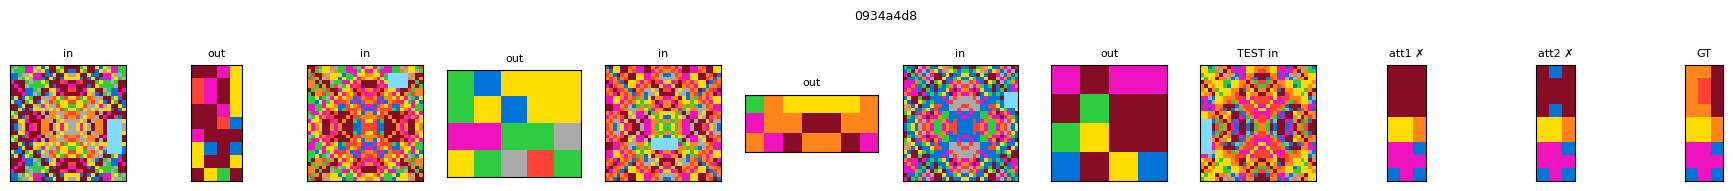

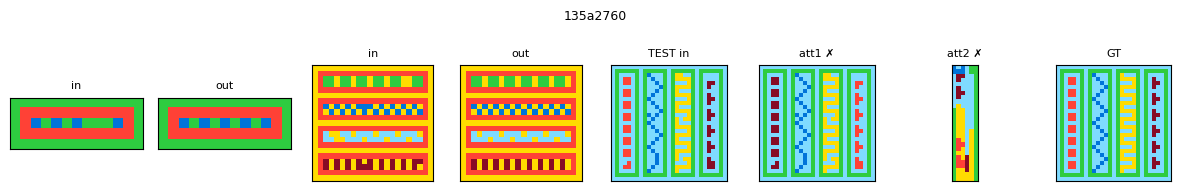

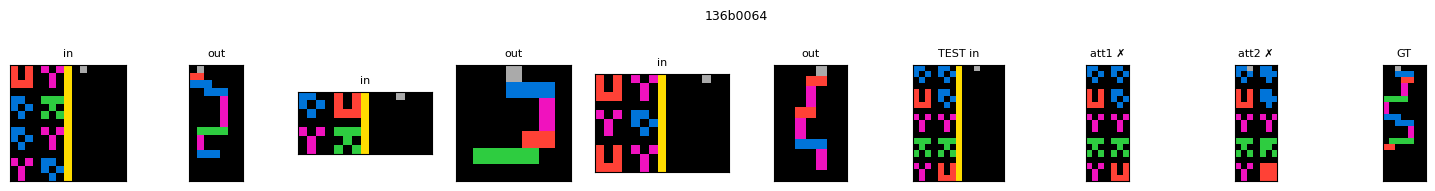

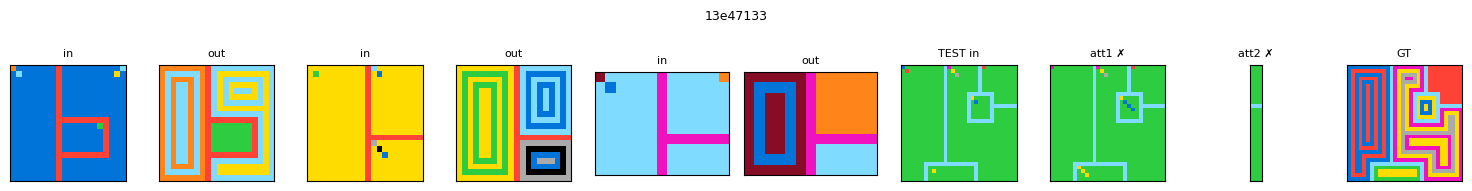

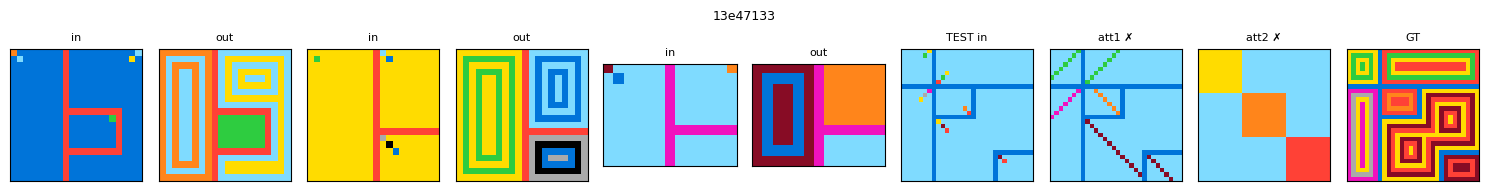

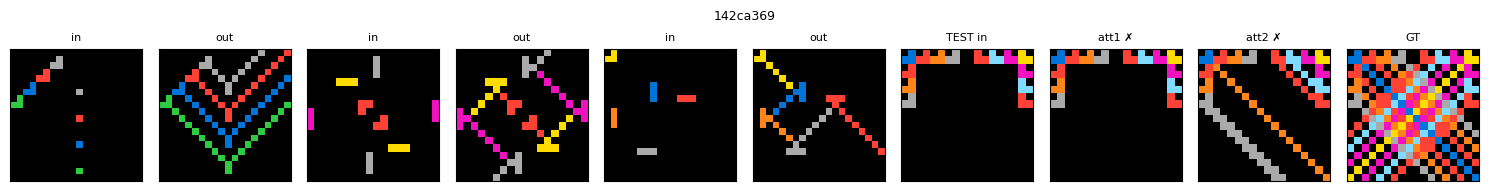

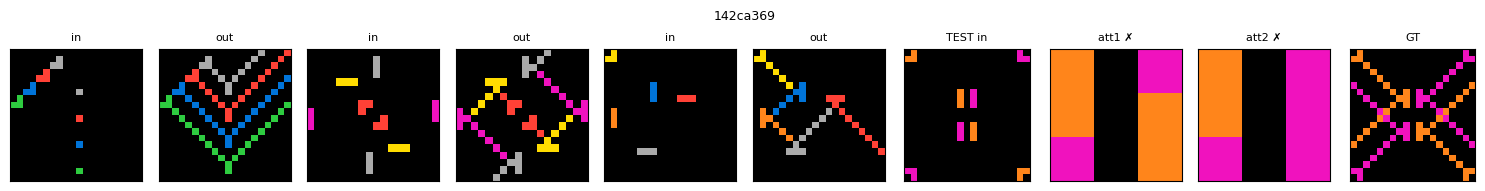

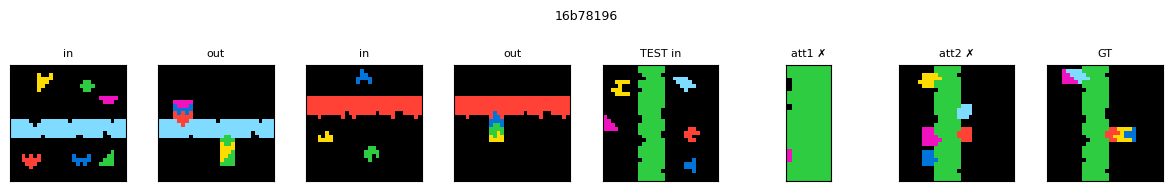

viz: rendered 6 task(s); set VIZ_N env to change


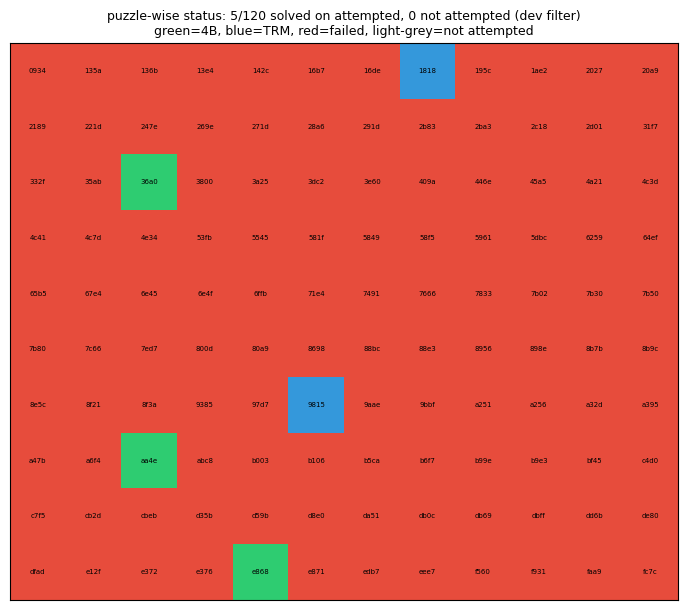

In [9]:
# ================= nvarc-viewer style visualization (DEV only) =================
import os, json
import numpy as np

if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
    print("viz: skipped in competition rerun")
else:
    from matplotlib import colors
    import matplotlib.pyplot as plt

    cmap = colors.ListedColormap([
        "#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
        "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25",
    ])
    norm = colors.Normalize(vmin=0, vmax=9)

    def show(ax, arr, title):
        arr = np.asarray(arr, dtype=np.uint8)
        ax.imshow(arr, cmap=cmap, norm=norm)
        ax.set_title(title, fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

    root = "/kaggle/input/competitions/arc-prize-2026-arc-agi-2"
    if not os.path.isdir(root):
        root = "/kaggle/input/arc-prize-2026-arc-agi-2"
    with open(f"{root}/arc-agi_evaluation_challenges.json") as f:
        challenges = json.load(f)
    try:
        with open(f"{root}/arc-agi_evaluation_solutions.json") as f:
            solutions = json.load(f)
    except Exception:
        solutions = {}
    with open("submission.json") as f:
        sub = json.load(f)

    VIZ_N = int(os.getenv("VIZ_N", "6"))

    def _nontrivial(nm):
        return any(a.get(f"attempt_{i}") != [[0]] for a in sub.get(nm, []) for i in (1, 2))

    ordered_names = sorted(challenges.keys(), key=lambda nm: (not _nontrivial(nm), nm))
    shown = 0
    for name in ordered_names:
        task = challenges[name]
        if name not in sub:
            continue
        for ti, tpair in enumerate(task["test"]):
            atts = sub[name][ti] if ti < len(sub[name]) else {}
            gt = solutions.get(name, [None] * len(task["test"]))[ti] if solutions else None
            ncols = len(task["train"]) * 2 + 3 + (1 if gt is not None else 0)
            fig, axes = plt.subplots(1, ncols, figsize=(1.5 * ncols, 1.9))
            k = 0
            for p in task["train"]:
                show(axes[k], p["input"], "in"); k += 1
                show(axes[k], p["output"], "out"); k += 1
            show(axes[k], tpair["input"], "TEST in"); k += 1
            for ai in (1, 2):
                g = atts.get(f"attempt_{ai}", [[0]])
                mark = "" if gt is None else (" \u2713" if g == gt else " \u2717")
                show(axes[k], g, f"att{ai}{mark}"); k += 1
            if gt is not None:
                show(axes[k], gt, "GT")
            fig.suptitle(name, fontsize=9)
            plt.tight_layout()
            plt.show()
        shown += 1
        if shown >= VIZ_N:
            break
    print(f"viz: rendered {shown} task(s); set VIZ_N env to change")

    # ---- puzzle-wise solve-status matrix over the whole evaluation set ----
    merge_info = {}
    try:
        with open("/kaggle/working/merge_stats.json") as f:
            merge_info = json.load(f)
    except Exception:
        pass
    trm_filled = {k.rsplit("_", 1)[0] for k in
                  merge_info.get("filled2", []) + merge_info.get("filled_both", [])}

    names = [n for n in challenges if n in sub]
    # 0 failed, 1 solved(4B), 2 solved(TRM-filled), 3 no GT, 4 not attempted
    status = []
    for nm in names:
        attempted = any(e.get(f"attempt_{a}") != [[0]] for e in sub[nm] for a in (1, 2))
        if not attempted:
            status.append(4)
            continue
        gt_list = solutions.get(nm)
        if not gt_list:
            status.append(3)
            continue
        ok = all(any(sub[nm][ti].get(f"attempt_{a}") == gt_list[ti] for a in (1, 2))
                 for ti in range(min(len(gt_list), len(sub[nm]))))
        status.append((2 if nm in trm_filled else 1) if ok else 0)

    ncol = 12
    nrow = (len(names) + ncol - 1) // ncol
    mat = np.full((nrow, ncol), -1, dtype=int)
    for idx, s in enumerate(status):
        mat[idx // ncol, idx % ncol] = s
    smap = colors.ListedColormap(["#FFFFFF", "#E74C3C", "#2ECC71", "#3498DB",
                                  "#888888", "#E8E8E8"])
    fig, ax = plt.subplots(figsize=(ncol * 0.62, max(2.0, nrow * 0.62)))
    ax.imshow(mat + 1, cmap=smap, vmin=0, vmax=5)
    for idx, nm in enumerate(names):
        ax.text(idx % ncol, idx // ncol, nm[:4], ha="center", va="center", fontsize=5)
    ax.set_xticks([]); ax.set_yticks([])
    n_scored = len([s for s in status if s not in (3, 4)])
    n_solved = len([s for s in status if s in (1, 2)])
    n_skip = len([s for s in status if s == 4])
    ax.set_title(f"puzzle-wise status: {n_solved}/{n_scored} solved on attempted, "
                 f"{n_skip} not attempted (dev filter)\n"
                 f"green=4B, blue=TRM, red=failed, light-grey=not attempted", fontsize=9)
    plt.tight_layout()
    plt.show()
